## Fase 2: Procesamiento de Señal y Extracción de Características

In [37]:
import os
import pandas as pd
import multiprocessing
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm 
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew
from scipy.fft import fft, fftfreq
from scipy.signal.windows import hamming
from scipy import signal

In [38]:
carpeta = '../../Datos/Originales/03_Validacion/bearing_fault_detection'

In [39]:
new_columns = ['tachometer', 'acc_under_axial','acc_under_radiale','acc_under_tangencial', 
               'acc_over_axial','acc_over_radiale','acc_over_tangencial','microphone']


## Dominio del Tiempo: Detección de Energía e Impactos
La siguiente función comprime la onda de vibración pura en estadísticos clave:
* **RMS (Root Mean Square):** Nos indica la energía global de la vibración (ideal para detectar desequilibrios o desgastes generales).
* **Curtosis y Asimetría (Skewness):** Miden qué tan "puntiaguda" es la onda. Un pico alto de curtosis es el síntoma principal de impactos metálicos bruscos, como una fisura en el rodamiento.

In [40]:
def extract_time_features(df, file_path):
    """
    Extrae características estadísticas del dominio del tiempo para cada columna 
    del acelerómetro y micrófono.
    """
    features = {}
    # Solo procesamos las columnas numéricas (vibraciones y micro)
    # Excluimos las columnas de texto (clase, subclase)
    cols_to_process = [c for c in df.columns if c not in ['clase', 'subclase', 'tachometer']]
    
    for col in cols_to_process:
        signal = df[col].values
        features[f'{col}_mean'] = np.mean(signal)
        features[f'{col}_std'] = np.std(signal)
        features[f'{col}_rms'] = np.sqrt(np.mean(signal**2))
        features[f'{col}_kurtosis'] = kurtosis(signal)
        features[f'{col}_skewness'] = skew(signal)
        features[f'{col}_max'] = np.max(signal)

    # Añadimos la información de contexto
    features['file_path'] = file_path
    features['clase'] = df['clase'].iloc[0]
    if 'subclase' in df.columns:
        features['subclase'] = df['subclase'].iloc[0]
        
    return pd.DataFrame([features])


## Dominio de la Frecuencia: Aislamiento del Fallo (Transformada de Fourier)
En un entorno industrial, la vibración del fallo está mezclada con el ruido del giro del motor. 

Utilizamos la **Transformada Rápida de Fourier (FFT)** para descomponer la señal y encontrar la frecuencia a la que ocurre el mayor pico de energía (`fft_dominant_freq`). Como cada pieza mecánica gira a una velocidad distinta, esto nos permitirá localizar la pieza exacta que está fallando.

In [41]:
def extract_fft_features(df, file_path, sampling_rate=51200):
    """
    Extrae características del dominio de la frecuencia usando la FFT.
    Identifica la magnitud de la frecuencia dominante.
    Aplica Detrend y Ventana de Hamming para evitar la fuga espectral.
    """
    fft_features = {}
    cols_to_process = [c for c in df.columns if c not in ['clase', 'subclase', 'tachometer']]
    
    for col in cols_to_process:
        sig = df[col].values
        n = len(sig)

        # Preprocesamiento
        sig_detrend = signal.detrend(sig) 
        ventana = hamming(n)
        sig_prep = sig_detrend * ventana
        
        # Cálculo de la FFT sobre la señal limpia (visto en el notebook 05)
        yf = fft(sig_prep)
        xf = fftfreq(n, 1/sampling_rate)
        
        # Tomamos solo la parte positiva del espectro
        abs_yf = np.abs(yf[:n//2])
        
        # Extraemos métricas del espectro
        fft_features[f'{col}_fft_max_amp'] = np.max(abs_yf)
        fft_features[f'{col}_fft_mean_amp'] = np.mean(abs_yf)
        
        # Frecuencia en la que ocurre el pico máximo
        idx_max = np.argmax(abs_yf)
        fft_features[f'{col}_fft_dominant_freq'] = xf[idx_max]

    fft_features['file_path'] = file_path
    fft_features['clase'] = df['clase'].iloc[0]
    if 'subclase' in df.columns:
        fft_features['subclase'] = df['subclase'].iloc[0]

    return pd.DataFrame([fft_features])


In [42]:
def process_file(file_path):
    """ Procesa un archivo CSV y extrae características de manera segura. """
    try:
        df = pd.read_csv(file_path, header=None)
        if len(df.columns) == len(new_columns):
            df.columns = new_columns
        
        # Obtener clase, subclase y donde a partir de la estructura del directorio
        relative_path = os.path.relpath(os.path.dirname(file_path), carpeta)
        parts = relative_path.split(os.sep)
        
        # Lógica para determinar las columnas 'clase', 'subclase' y 'donde'
        if parts[0] == 'normal':
            df['clase'] = parts[0]
        elif len(parts) > 2:  # Para los valores de OVERHANG y UNDERHANG
            df['clase'] = f'{parts[0]}_{parts[1]}'
            df['subclase'] = parts[2]
        else:  # Para el resto de valores
            df['clase'] = parts[0]
            df['subclase'] = parts[1]

        # Extraer características
        features_df = extract_time_features(df, file_path)
        fft_features_df = extract_fft_features(df, file_path, sampling_rate=51200)

        return features_df, fft_features_df

    except Exception as e:
        print(f'Error en archivo {file_path}: {e}')
        return None, None

## Estrategia Multidominio
Para cumplir con los criterios de excelencia del proyecto, no mezclaremos todas las características en un solo archivo. 

Procederemos a separar la extracción en dos *datasets* independientes:
1. `features_dom_tiempo.csv`: Contiene la energía e impactos globales.
2. `features_dom_frecuencia.csv`: Contiene las firmas espectrales de los rodamientos.

Esta separación estratégica nos permitirá realizar una **comparativa de capacidad predictiva entre dominios** en la siguiente fase de modelado, demostrando qué enfoque es más eficiente para cada tipo de anomalía.

In [44]:
if __name__ == "__main__": 
    archivos_csv = [os.path.join(subdir, file) 
                    for subdir, _, files in os.walk(carpeta) 
                    for file in files if file.endswith('.csv')]

    num_workers = min(6, multiprocessing.cpu_count())  # Ajustar el número de workers

    all_features = []
    all_features_fft = []

    # Barra de progreso en el loop de archivos
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(process_file, file): file for file in archivos_csv}
        
        # Usar tqdm para la barra de progreso
        for future in tqdm(as_completed(futures), total=len(futures), desc="Procesando archivos"):
            try:
                features_df, fft_features_df = future.result()
                if features_df is not None and fft_features_df is not None:
                    all_features.append(features_df)
                    all_features_fft.append(fft_features_df)
            except Exception as e:
                print(f'Error en el procesamiento paralelo: {e}')

    # Guardar los resultados si hay datos
    if all_features:
        final_features_df = pd.concat(all_features, ignore_index=True)
        final_features_df.to_csv('../../Datos/Transformados/features_dom_tiempo.csv', index=False)
        print("Archivo `features_dom_tiempo.csv` guardado correctamente.")

    if all_features_fft:
        final_features_fft_df = pd.concat(all_features_fft, ignore_index=True)
        final_features_fft_df.to_csv('../../Datos/Transformados/features_dom_frecuencia.csv', index=False)
        print("Archivo `features_dom_frecuencia.csv` guardado correctamente.")

    print("Proceso finalizado.")



Procesando archivos: 100%|██████████| 1951/1951 [09:47<00:00,  3.32it/s]


Archivo `features_dom_tiempo.csv` guardado correctamente.
Archivo `features_dom_frecuencia.csv` guardado correctamente.
Proceso finalizado.


## Dualidad Tiempo-Frecuencia
Antes de pasar a la fase de Machine Learning, es fundamental validar visualmente que nuestras matemáticas funcionan. 

A continuación, creamos una herramienta gráfica que toma la onda de vibración original (dominio del tiempo) y muestra su espectro de frecuencias (dominio de la frecuencia). Ejecutaremos esta visualización comparando tres escenarios:
1. Un motor en estado **Normal**.
2. Un motor con **Desalineación Vertical**.
3. Un motor con **Desalineación Horizontal**.

*Nota: Observaremos cómo la frecuencia dominante (el pico del espectro) cambia de posición o magnitud en presencia de una avería.*

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def visualizar_transformada_motor(file_path, nombre_columna='acc_under_axial', col_index=1, sampling_rate=51200):
    """
    Toma un archivo CSV de vibración y grafica su dominio del tiempo
    y su transformación al dominio de la frecuencia (FFT).
    """
    # 1. Cargar los datos
    df = pd.read_csv(file_path, header=None)
    
    # AQUÍ ESTÁ LA MAGIA: Ahora usa el índice que le pasemos
    senal = df.iloc[:, col_index].values 
    
    N = len(senal)
    tiempo = np.linspace(0, N / sampling_rate, N, endpoint=False)
    
    # 2. Calcular la FFT 
    yf = fft(senal)
    xf = fftfreq(N, 1 / sampling_rate)
    
    xf_pos = xf[:N//2]
    yf_mag = np.abs(yf[:N//2])
    
    idx_max = np.argmax(yf_mag)
    freq_dominante = xf_pos[idx_max]
    amp_maxima = yf_mag[idx_max]

    # 3. Crear la visualización
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(f'Vibration Analysis: {nombre_columna} | File: {file_path.split("/")[-1]}', fontsize=16, fontweight='bold')

    # Gráfica 1
    muestras_a_mostrar = 5000 
    ax1.plot(tiempo[:muestras_a_mostrar], senal[:muestras_a_mostrar], color='teal', alpha=0.8)
    ax1.set_title('Time Domain (Original Waveform)')
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Amplitude (Acceleration)')
    ax1.grid(True, alpha=0.3)

    # Gráfica 2
    ax2.plot(xf_pos, yf_mag, color='crimson', alpha=0.8)
    ax2.set_title('Frequency Domain (FFT Spectrum)')
    ax2.set_xlabel('Frequency [Hz]')
    ax2.set_ylabel('Magnitude')
    ax2.grid(True, alpha=0.3)
    
    ax2.annotate(f'Dominant Peak: {freq_dominante:.1f} Hz', 
                 xy=(freq_dominante, amp_maxima), 
                 xytext=(freq_dominante + 1000, amp_maxima),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 fontsize=12, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

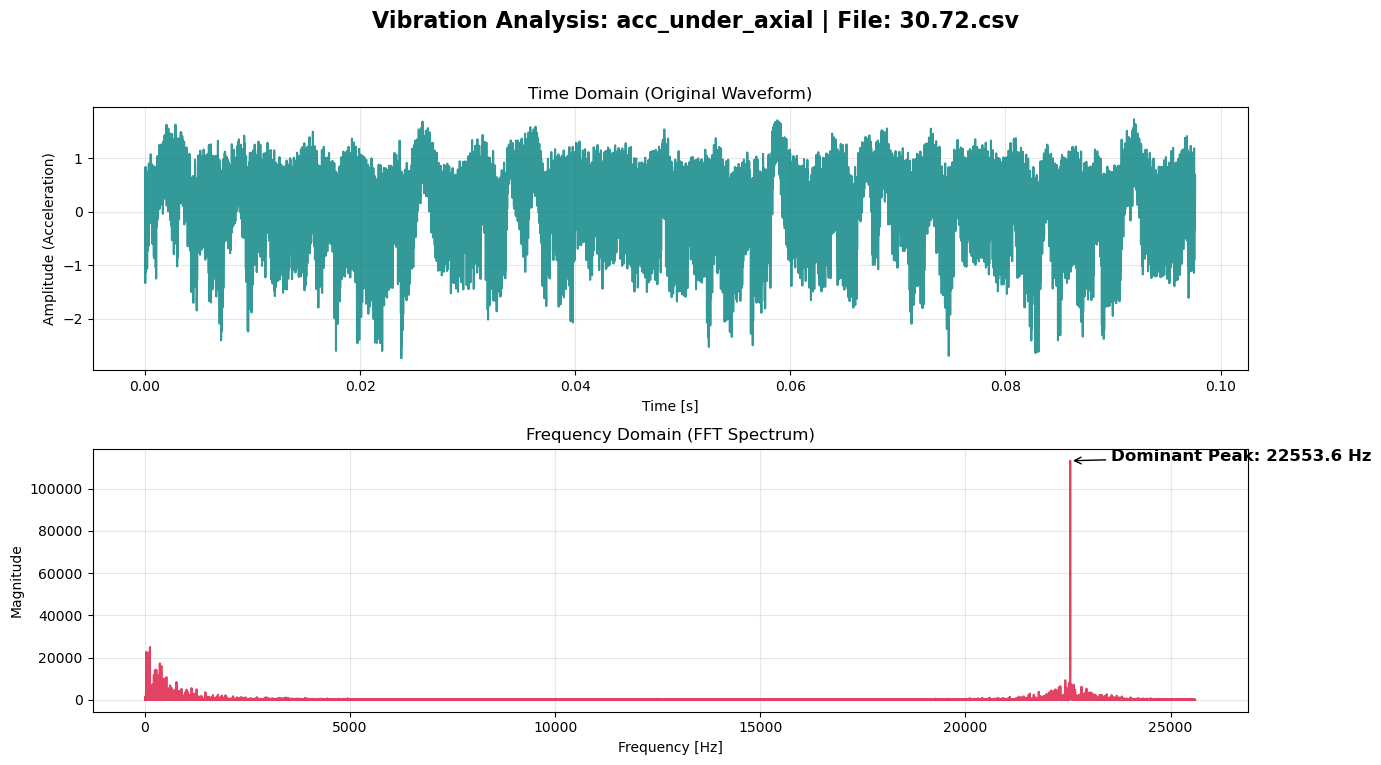

In [46]:
# 1. MOTOR SANO (Sensor Axial)
ejemplo_sano = '../../Datos/Originales/03_Validacion/bearing_fault_detection_reduced/normal/30.72.csv'
visualizar_transformada_motor(ejemplo_sano, nombre_columna='acc_under_axial', col_index=1)

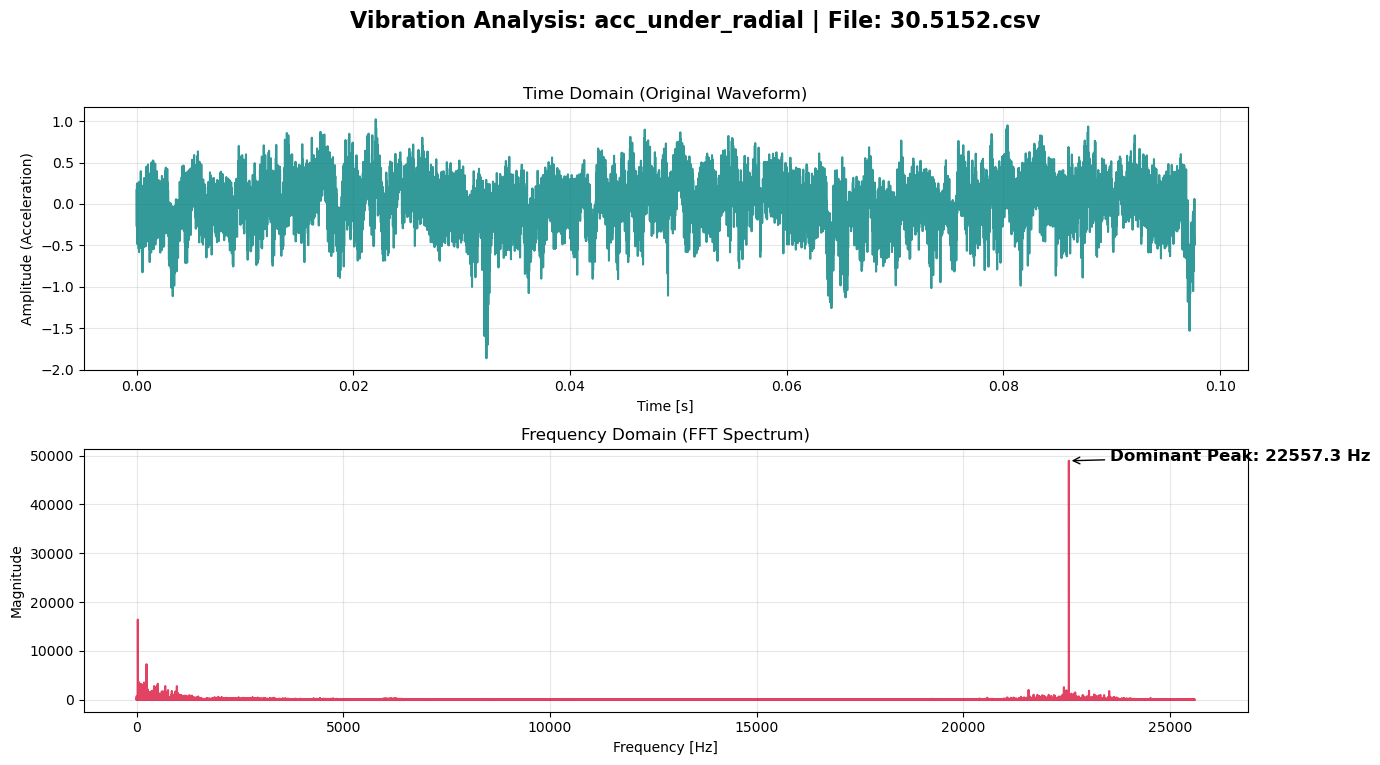

In [47]:
# 2. DESALINEACIÓN VERTICAL (Sensor Radial/Vertical)
ejemplo_vertical = '../../Datos/Originales/03_Validacion/bearing_fault_detection_reduced/vertical-misalignment/0.51mm/30.5152.csv'
visualizar_transformada_motor(ejemplo_vertical, nombre_columna='acc_under_radial', col_index=2)

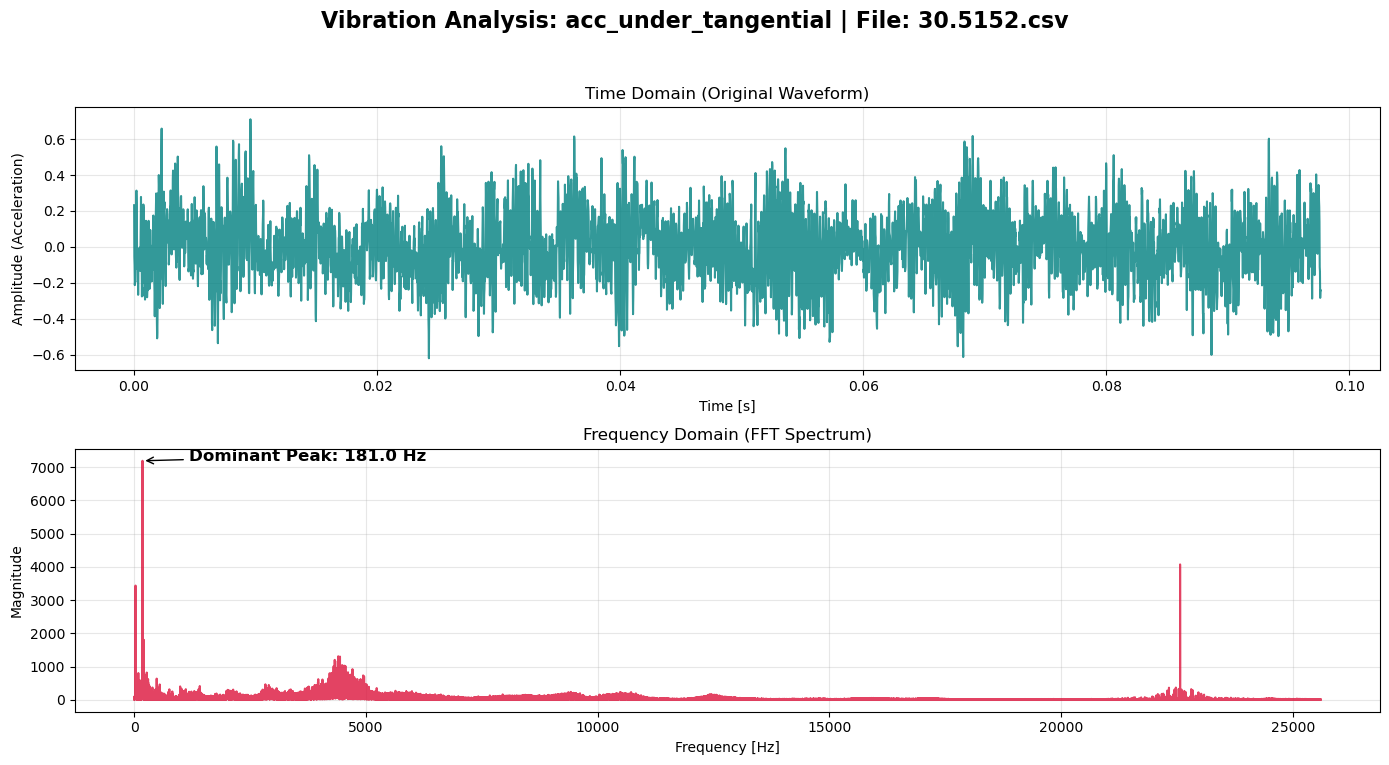

In [48]:
# 3. DESALINEACIÓN HORIZONTAL (Sensor Tangencial/Horizontal)
ejemplo_horizontal = '../../Datos/Originales/03_Validacion/bearing_fault_detection_reduced/horizontal-misalignment/1.5mm/30.5152.csv'
visualizar_transformada_motor(ejemplo_horizontal, nombre_columna='acc_under_tangential', col_index=3)